### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder

### Configurations

In [2]:
data_path = "data/main.csv"

## Exploratory Data Analysis

In [3]:
db_main = pd.read_csv(data_path)
db_main.head()

C:\Users\apoor\AppData\Local\Temp\ipykernel_2712\3709795038.py:1: DtypeWarning: Columns (0: length_of_stay) have mixed types. Specify dtype option on import or set low_memory=False.
  db_main = pd.read_csv(data_path)


,health_service_area,hospital_county,operating_certificate_number,facility_id,facility_name,age_group,zip_code_3_digits,gender,race,ethnicity,...,apr_risk_of_mortality,apr_medical_surgical_description,payment_typology_1,birth_weight,abortion_edit_indicator,emergency_department_indicator,total_charges,total_costs,payment_typology_2,payment_typology_3
0,New York City,Bronx,7000001,1164,Bronx-Lebanon Hospital Center - Fulton Division,30 to 49,114,M,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,8225.00,7341.60,NaN,NaN
1,New York City,Bronx,7000002,1165,Jacobi Medical Center,30 to 49,104,M,Black/African American,Not Span/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,4846.76,2801.79,NaN,NaN
2,New York City,Bronx,7000002,1165,Jacobi Medical Center,0 to 17,104,M,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,17205.30,9945.95,Medicaid,NaN
3,New York City,Bronx,7000002,1165,Jacobi Medical Center,30 to 49,104,F,Black/African American,Not Span/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,9132.22,5279.11,NaN,NaN
4,New York City,Bronx,7000002,1165,Jacobi Medical Center,0 to 17,104,F,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,6645.30,3841.48,NaN,NaN


In [4]:
print(db_main.shape)

(1074266, 34)


In [5]:
db_main.describe()

,operating_certificate_number,facility_id,discharge_year,ccs_diagnosis_code,ccs_procedure_code,apr_drg_code,apr_mdc_code,apr_severity_of_illness_code,birth_weight,total_charges,total_costs
count,1.074266e+06,1.074266e+06,1074266.0,1.074266e+06,1.074266e+06,1.074266e+06,1.074266e+06,1.074266e+06,1.074266e+06,1.074266e+06,1.074266e+06
mean,7.001757e+06,1.536749e+03,2016.0,1.911833e+02,1.260381e+02,4.222416e+02,1.046386e+01,1.984083e+00,3.553025e+02,5.214307e+04,1.843149e+04
std,1.095956e+03,4.766993e+02,0.0,1.623053e+02,8.921728e+01,2.425817e+02,5.889489e+00,8.984639e-01,1.020741e+03,9.981903e+04,3.956700e+04
min,7.000001e+06,1.164000e+03,2016.0,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-02,0.000000e+00
25%,7.001020e+06,1.305000e+03,2016.0,1.020000e+02,4.300000e+01,2.010000e+02,5.000000e+00,1.000000e+00,0.000000e+00,1.431285e+04,5.195800e+03
50%,7.002020e+06,1.454000e+03,2016.0,1.590000e+02,1.370000e+02,4.200000e+02,1.000000e+01,2.000000e+00,0.000000e+00,2.773097e+04,9.733965e+03
75%,7.002054e+06,1.629000e+03,2016.0,2.180000e+02,2.180000e+02,6.400000e+02,1.500000e+01,3.000000e+00,0.000000e+00,5.603154e+04,1.926507e+04
max,7.004010e+06,3.975000e+03,2016.0,9.990000e+02,9.990000e+02,9.560000e+02,2.500000e+01,4.000000e+00,9.000000e+03,1.047750e+07,5.870820e+06


In [6]:
db_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074266 entries, 0 to 1074265
Data columns (total 34 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   health_service_area                  1074266 non-null  str    
 1   hospital_county                      1074266 non-null  str    
 2   operating_certificate_number         1074266 non-null  int64  
 3   facility_id                          1074266 non-null  int64  
 4   facility_name                        1074266 non-null  str    
 5   age_group                            1074266 non-null  str    
 6   zip_code_3_digits                    1057732 non-null  str    
 7   gender                               1074266 non-null  str    
 8   race                                 1074266 non-null  str    
 9   ethnicity                            1074266 non-null  str    
 10  length_of_stay                       1074266 non-null  object 
 11  type_of_a

In [7]:
columns_for_the_table = [
    "health_service_area", 
    "age_group", 
    "gender", 
    "race", 
    "type_of_admission", 
    "patient_disposition", 
    "ccs_diagnosis_code", 
    "ccs_procedure_code", 
    "apr_drg_code", 
    "apr_mdc_code", 
    "apr_severity_of_illness_code", 
    "apr_risk_of_mortality", 
    "birth_weight", 
    "abortion_edit_indicator", 
    "emergency_department_indicator", 
    "length_of_stay"
]

### Selecting the features which are intuitively more important for the model and removing non relevant ones like payment and description features.

In [8]:
db = db_main[columns_for_the_table]
db.head()

,health_service_area,age_group,gender,race,type_of_admission,patient_disposition,ccs_diagnosis_code,ccs_procedure_code,apr_drg_code,apr_mdc_code,apr_severity_of_illness_code,apr_risk_of_mortality,birth_weight,abortion_edit_indicator,emergency_department_indicator,length_of_stay
0,New York City,30 to 49,M,Other Race,Emergency,Home or Self Care,657,0,753,19,1,Minor,0,N,Y,3
1,New York City,30 to 49,M,Black/African American,Emergency,Home or Self Care,657,218,753,19,1,Minor,0,N,Y,3
2,New York City,0 to 17,M,Other Race,Emergency,Home or Self Care,128,231,141,4,2,Minor,0,N,Y,3
3,New York City,30 to 49,F,Black/African American,Emergency,Home or Self Care,657,218,753,19,1,Minor,0,N,Y,6
4,New York City,0 to 17,F,Other Race,Emergency,Home or Self Care,128,231,141,4,1,Minor,0,N,Y,1


### Check Null Values

In [9]:
db.isna().sum()

health_service_area                0
age_group                          0
gender                             0
race                               0
type_of_admission                  0
patient_disposition                0
ccs_diagnosis_code                 0
ccs_procedure_code                 0
apr_drg_code                       0
apr_mdc_code                       0
apr_severity_of_illness_code       0
apr_risk_of_mortality             31
birth_weight                       0
abortion_edit_indicator            0
emergency_department_indicator     0
length_of_stay                     0
dtype: int64

### Check the destribution of each feature

### Destribution of categorical data

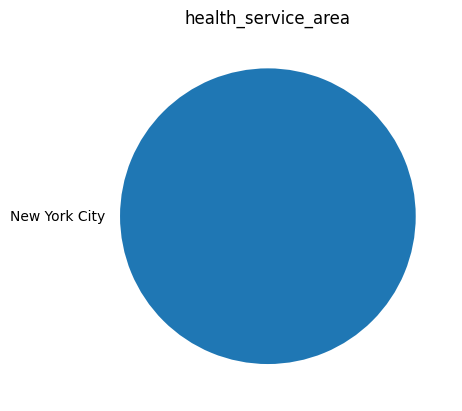

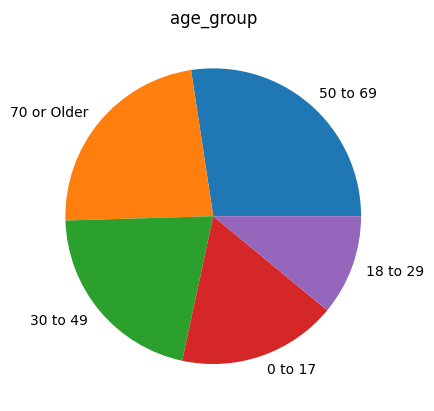

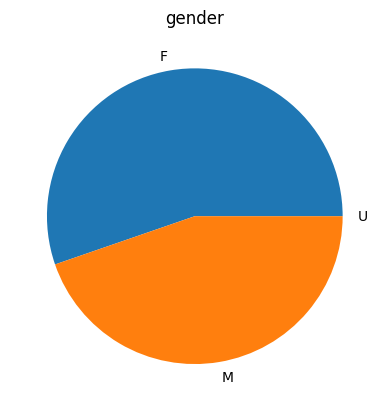

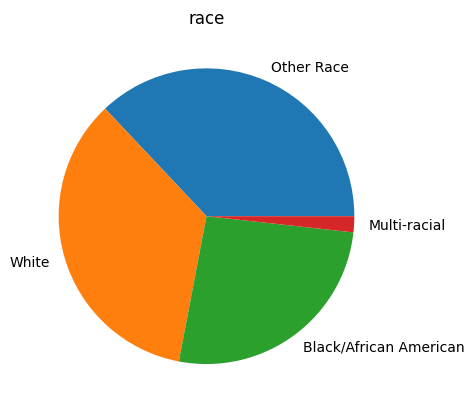

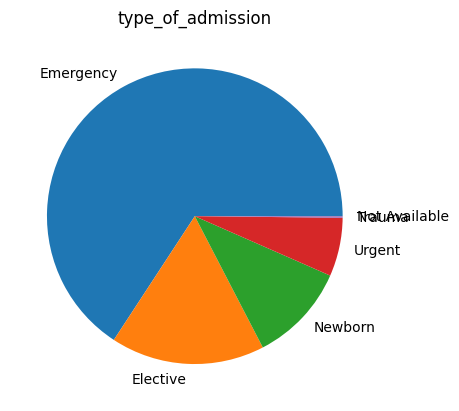

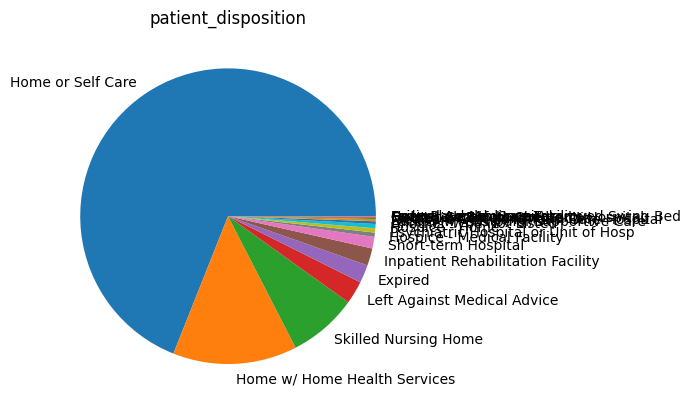

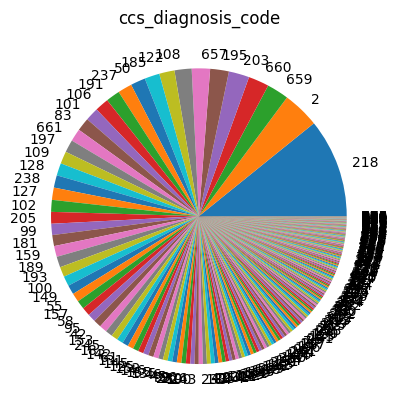

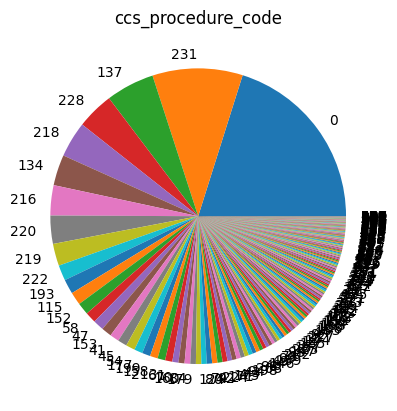

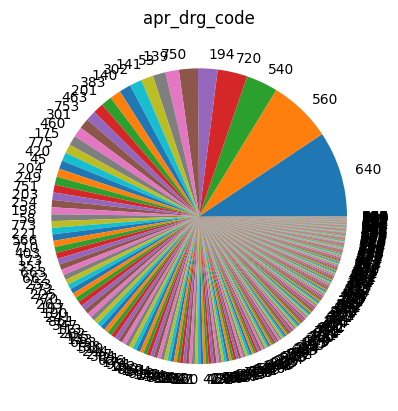

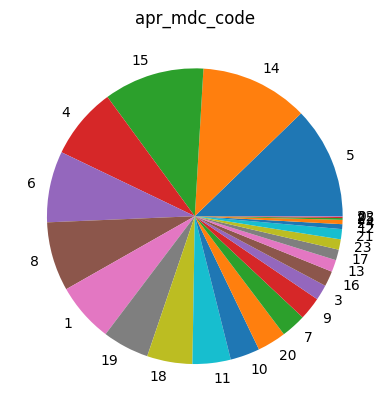

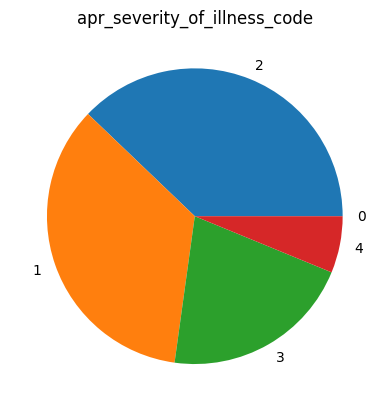

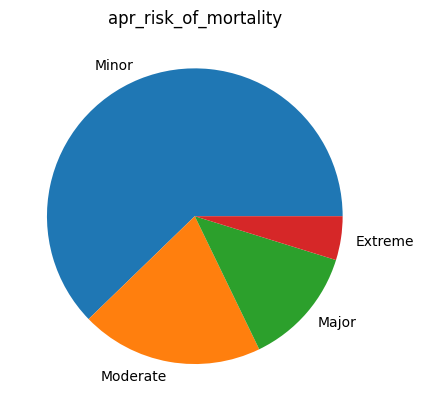

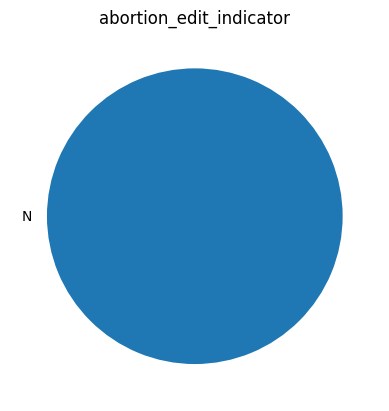

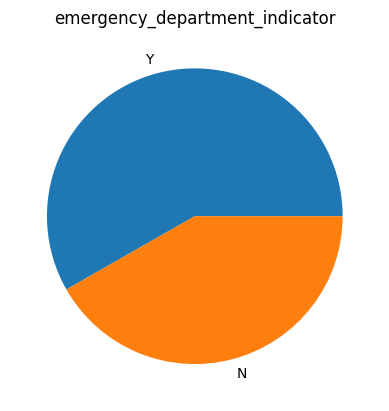

In [10]:
plots_to_make = [
    "health_service_area",
    "age_group",
    "gender",
    "race",
    "type_of_admission",
    "patient_disposition",
    "ccs_diagnosis_code",
    "ccs_procedure_code",
    "apr_drg_code",
    "apr_mdc_code",
    "apr_severity_of_illness_code",
    "apr_risk_of_mortality",
    "abortion_edit_indicator",
    "emergency_department_indicator"
]
for i in plots_to_make:
    counts_for_hs = db[i].value_counts()
    labels = counts_for_hs.index
    values = counts_for_hs.values

# Plot the chart
    plt.pie(values, labels=labels)
    plt.title(i)
    plt.show()

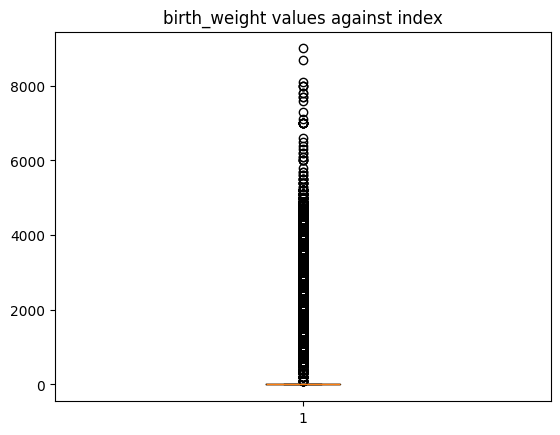

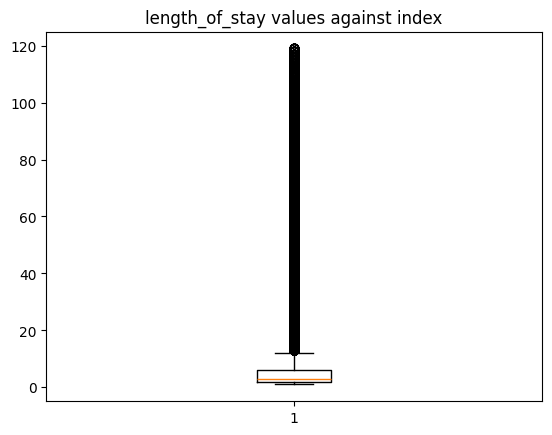

In [11]:
plots_to_make_numerical = ["birth_weight", "length_of_stay"]
for i in plots_to_make_numerical:
    col = pd.to_numeric(db[i], errors='coerce').dropna()
    plt.boxplot(col)
    plt.title(f"{i} values against index")
    plt.show()

In [12]:
codes_features = ["ccs_diagnosis_code", "ccs_procedure_code", "apr_drg_code", "apr_mdc_code"]
for i in codes_features:
    print(f"Unique categories in {i}: {db[i].nunique()}")


Unique categories in ccs_diagnosis_code: 260
Unique categories in ccs_procedure_code: 224
Unique categories in apr_drg_code: 314
Unique categories in apr_mdc_code: 26


1. Scale Birth weight
2. One Hot Encode Features
3. Normalize birth weight column
4. Handle Codes features

## One hot encoding for the features with less number of unique categories

In [13]:
def one_hot_encoder(df_list: list):
    encoder = OneHotEncoder(dtype=int, sparse_output=False).set_output(transform="pandas")
    df_transformed = pd.DataFrame()
    for i in df_list:
        if isinstance(db[[i]],pd.DataFrame):
           result = encoder.fit_transform(db[[i]])
           df_transformed = pd.concat([df_transformed,result], axis=1)
    return df_transformed
    
encoders_needed_with_one_hot = [
    "health_service_area",
    "age_group",
    "gender",
    "race",
    "type_of_admission",
    "patient_disposition",
    "ccs_diagnosis_code",
    "ccs_procedure_code",
    "apr_drg_code",
    "apr_mdc_code",
    "apr_severity_of_illness_code",
    "apr_risk_of_mortality",
    "abortion_edit_indicator",
    "emergency_department_indicator"
]
encoders_needed_with_label_encoding = ["ccs_diagnosis_code", "ccs_procedure_code", "apr_drg_code", "apr_mdc_code"]
df1 = one_hot_encoder(encoders_needed_with_one_hot)
df1.head()

,health_service_area_New York City,age_group_0 to 17,age_group_18 to 29,age_group_30 to 49,age_group_50 to 69,age_group_70 or Older,gender_F,gender_M,gender_U,race_Black/African American,...,apr_severity_of_illness_code_3,apr_severity_of_illness_code_4,apr_risk_of_mortality_Extreme,apr_risk_of_mortality_Major,apr_risk_of_mortality_Minor,apr_risk_of_mortality_Moderate,apr_risk_of_mortality_nan,abortion_edit_indicator_N,emergency_department_indicator_N,emergency_department_indicator_Y
0,1,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,1
1,1,0,0,1,0,0,0,1,0,1,...,0,0,0,0,1,0,0,1,0,1
2,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,1
3,1,0,0,1,0,0,1,0,0,1,...,0,0,0,0,1,0,0,1,0,1
4,1,1,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,1


## Target Encoding for features with multiple unique categories

In [14]:
def target_encoder(df_list: list):
    encoder = TargetEncoder(smooth="auto", cv=5).set_output(transform="pandas")
    y = pd.to_numeric(db["length_of_stay"].astype(str).str.replace("+", "", regex=False).str.strip(), errors='coerce')
    y = y.fillna(y.median()) 
    df_transformed = pd.DataFrame()
    for i in df_list:
        if isinstance(db[[i]], pd.DataFrame):
           result = encoder.fit_transform(db[[i]], y)
           df_transformed = pd.concat([df_transformed,result], axis=1)
    return df_transformed
    
encoders_needed_with_label_encoding = ["ccs_diagnosis_code", "ccs_procedure_code", "apr_drg_code", "apr_mdc_code"]
df2 = target_encoder(encoders_needed_with_label_encoding)
df2.head()

,ccs_diagnosis_code_1,ccs_diagnosis_code_2,ccs_diagnosis_code_3,ccs_diagnosis_code_4,ccs_diagnosis_code_5,ccs_diagnosis_code_6,ccs_diagnosis_code_7,ccs_diagnosis_code_8,ccs_diagnosis_code_9,ccs_diagnosis_code_10,...,apr_mdc_code_111,apr_mdc_code_112,apr_mdc_code_113,apr_mdc_code_114,apr_mdc_code_115,apr_mdc_code_116,apr_mdc_code_117,apr_mdc_code_118,apr_mdc_code_119,apr_mdc_code_120
0,0.078679,0.064724,0.066235,0.051115,0.056464,0.065184,0.077334,0.064192,0.053319,0.046864,...,0.000160,0.000137,0.000091,0.000114,0.000183,0.000069,0.000114,0.000091,0.000091,0.005374
1,0.076962,0.063941,0.064644,0.052559,0.055139,0.065813,0.076016,0.065750,0.055075,0.046570,...,0.000138,0.000115,0.000115,0.000183,0.000183,0.000092,0.000138,0.000092,0.000115,0.005341
2,0.345959,0.284345,0.152120,0.085659,0.050793,0.027721,0.016530,0.011622,0.005768,0.003960,...,0.000000,0.000015,0.000015,0.000030,0.000015,0.000000,0.000000,0.000000,0.000000,0.001744
3,0.076570,0.064180,0.065524,0.050969,0.053481,0.065695,0.080128,0.063062,0.053651,0.047397,...,0.000137,0.000160,0.000068,0.000114,0.000137,0.000068,0.000091,0.000137,0.000114,0.005133
4,0.345888,0.283477,0.156647,0.085583,0.049711,0.027589,0.015887,0.010592,0.004954,0.003929,...,0.000000,0.000015,0.000030,0.000030,0.000030,0.000000,0.000000,0.000015,0.000015,0.001753


### Creating Final DF

In [15]:
dfFinal = pd.concat([df1,df2], axis=1)
dfFinal.shape

(1074266, 1355)

In [16]:
dfFinal.to_csv("data/transformed.csv", index=False)